
Ge_R1s(r) =
+356.4182 * exp(-32.7208 r)
+251.2204 * r * exp(-27.8041 r)
-0.7653 * r * exp(-14.4020 r)
+1250.4475 * r^2 * exp(-40.2593 r)
-0.3011 * r^2 * exp(-10.8267 r)
-0.0161 * r^2 * exp(-7.4435 r)
+0.0000 * r^2 * exp(-5.0894 r)
+26.7998 * r^3 * exp(-17.0698 r)
-0.0000 * r^3 * exp(-3.0282 r)
+0.0000 * r^3 * exp(-1.9965 r)
-0.0000 * r^3 * exp(-1.3445 r)

Ge_R2s(r) =
-110.8405 * exp(-32.7208 r)
-984.9383 * r * exp(-27.8041 r)
+907.8844 * r * exp(-14.4020 r)
-38.2309 * r^2 * exp(-40.2593 r)
+205.6414 * r^2 * exp(-10.8267 r)
-3.5149 * r^2 * exp(-7.4435 r)
+0.4134 * r^2 * exp(-5.0894 r)
+3964.4804 * r^3 * exp(-17.0698 r)
-0.0070 * r^3 * exp(-3.0282 r)
+0.0006 * r^3 * exp(-1.9965 r)
-0.0000 * r^3 * exp(-1.3445 r)

Ge_R3s(r) =
-42.7196 * exp(-32.7208 r)
-446.3385 * r * exp(-27.8041 r)
+417.1877 * r * exp(-14.4020 r)
-108.2336 * r^2 * exp(-40.2593 r)
+213.1823 * r^2 * exp(-10.8267 r)
-289.0144 * r^2 * exp(-7.4435 r)
-76.9469 * r^2 * exp(-5.0894 r)
+4419.5245 * r^3 * exp(-17.0698 r)
-0.1356 

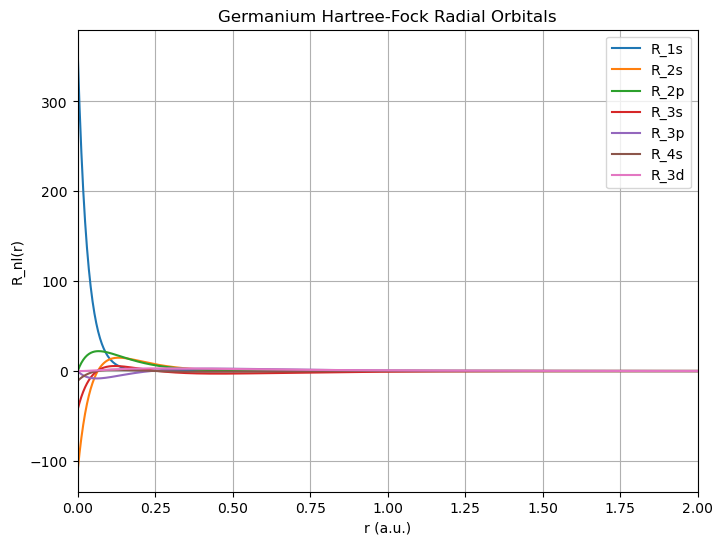

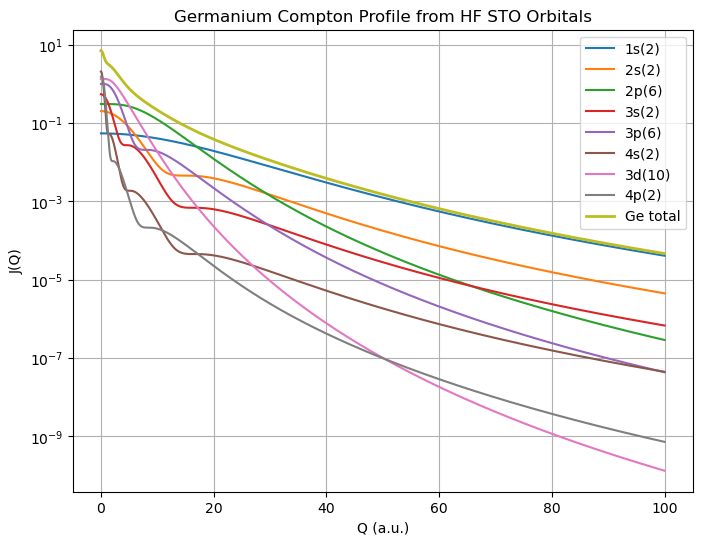

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Germanium Hartree-Fock STO data
# Ge: 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p2
# Format: (n_j, Z_j, C_j)
# =====================================================

germanium_1s = [
    (1, 32.7208,  0.952125),
    (2, 27.8041,  0.053372),
    (2, 14.4020, -0.000842),
    (3, 40.2593,  0.007163),
    (3, 10.8267, -0.000171),
    (3,  7.4435, -0.000034),
    (3,  5.0894,  0.000000),
    (4, 17.0698,  0.000678),
    (4,  3.0282, -0.000003),
    (4,  1.9965,  0.000003),
    (4,  1.3445, -0.000001),
]

germanium_2s = [
    (1, 32.7208, -0.296096),
    (2, 27.8041, -0.209251),
    (2, 14.4020,  0.998859),
    (3, 40.2593, -0.000219),
    (3, 10.8267,  0.116798),
    (3,  7.4435, -0.007409),
    (3,  5.0894,  0.003297),
    (4, 17.0698,  0.100296),
    (4,  3.0282, -0.000427),
    (4,  1.9965,  0.000245),
    (4,  1.3445, -0.000082),
]

germanium_3s = [
    (1, 32.7208, -0.114120),
    (2, 27.8041, -0.094825),
    (2, 14.4020,  0.458992),
    (3, 40.2593, -0.000620),
    (3, 10.8267,  0.121081),
    (3,  7.4435, -0.609201),
    (3,  5.0894, -0.613648),
    (4, 17.0698,  0.111808),
    (4,  3.0282, -0.008224),
    (4,  1.9965,  0.001917),
    (4,  1.3445, -0.000560),
]

germanium_4s = [
    (1, 32.7208, -0.029258),
    (2, 27.8041, -0.024840),
    (2, 14.4020,  0.120324),
    (3, 40.2593, -0.000142),
    (3, 10.8267,  0.036502),
    (3,  7.4435, -0.191413),
    (3,  5.0894, -0.182649),
    (4, 17.0698,  0.032523),
    (4,  3.0282,  0.352753),
    (4,  1.9965,  0.546670),
    (4,  1.3445,  0.232419),
]

germanium_2p = [
    (2, 32.3720,  0.074659),
    (2, 12.2227,  0.685414),
    (3, 26.6070,  0.165218),
    (3,  8.7258,  0.018146),
    (3,  5.8410, -0.000114),
    (3,  4.0849,  0.000755),
    (4, 21.4919,  0.112519),
    (4,  2.5444, -0.000060),
    (4,  1.5873,  0.000027),
    (4,  1.0280, -0.000010),
]

germanium_3p = [
    (2, 32.3720, -0.013603),
    (2, 12.2227, -0.435326),
    (3, 26.6070, -0.021515),
    (3,  8.7258,  0.252229),
    (3,  5.8410,  0.623458),
    (3,  4.0849,  0.297367),
    (4, 21.4919,  0.003214),
    (4,  2.5444,  0.003686),
    (4,  1.5873,  0.000284),
    (4,  1.0280,  0.000030),
]

germanium_4p = [
    (2, 32.3720, -0.002241),
    (2, 12.2227, -0.090957),
    (3, 26.6070,  0.002950),
    (3,  8.7258,  0.056839),
    (3,  5.8410,  0.145276),
    (3,  4.0849,  0.045219),
    (4, 21.4919,  0.001935),
    (4,  2.5444, -0.299040),
    (4,  1.5873, -0.543013),
    (4,  1.0280, -0.283008),
]

germanium_3d = [
    (3, 16.4691,  0.016414),
    (3,  9.0439,  0.229546),
    (3,  5.6272,  0.422554),
    (3,  3.4888,  0.381489),
    (3,  2.1980,  0.086376),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
R1s = R_nl(r, germanium_1s)
R2s = R_nl(r, germanium_2s)
R3s = R_nl(r, germanium_3s)
R4s = R_nl(r, germanium_4s)
R2p = R_nl(r, germanium_2p)
R3p = R_nl(r, germanium_3p)
R4p = R_nl(r, germanium_4p)
R3d = R_nl(r, germanium_3d)

print_R_formula(germanium_1s, "Ge_R1s")
print_R_formula(germanium_2s, "Ge_R2s")
print_R_formula(germanium_3s, "Ge_R3s")
print_R_formula(germanium_4s, "Ge_R4s")
print_R_formula(germanium_2p, "Ge_R2p")
print_R_formula(germanium_3p, "Ge_R3p")
print_R_formula(germanium_3d, "Ge_R3d")
print_R_formula(germanium_4p, "Ge_R4p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4p = chi_p(p, r, R4p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4p, J_4p = calculate_J(p, chi_4p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))
print("Norm 4p =", np.trapezoid(I_4p, p))

# Ge has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(2)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + 2*J_4s + 2*J_4p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s(2)": J_1s,
    "J_2s(2)": J_2s,
    "J_2p(6)": J_2p,
    "J_3s(2)": J_3s,
    "J_3p(6)": J_3p,
    "J_3d(10)": J_3d,
    "J_4s(2)": J_4s,
    "J_4p(2)": J_4p,
    "J_total_Ge": J_total
    })
print(table)
table.to_csv("Germanium_1_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Germanium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, 2*J_4p, label="4p(2)")
plt.plot(Q, J_total, label="Ge total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Germanium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()